# Range69 + PreMarket Statistics

Notebook này đọc `combined_1_7_dedup.csv`, dựng lại Range69 và PreMarket theo indicator `Session_high_low.txt`, rồi thống kê xác suất break, return, continue, và các mức `0.33 / 0.66`.

Giả định đang dùng: dữ liệu CSV là giờ Việt Nam `UTC+7`, indicator dùng timezone cố định `UTC-4`, nên thời gian indicator = thời gian CSV trừ 11 giờ.

In [18]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = Path('/Users/nguyenvokhang/Downloads/quant-research/combined_1_7_dedup.csv')
OUT_DAILY_STATS = Path('/Users/nguyenvokhang/Downloads/quant-research/range69_premarket_daily_stats.csv')
OUT_CHART = Path('/Users/nguyenvokhang/Downloads/quant-research/range69_premarket_latest_chart.png')

# Indicator sessions in fixed UTC-4 minutes from midnight.
RANGE69_START = 6 * 60
RANGE69_END = 8 * 60 + 59
PREMARKET_START = 7 * 60
PREMARKET_END = 9 * 60
POST_START = 9 * 60 + 1
POST_END = 16 * 60 + 14

CSV_TO_INDICATOR_HOURS = -11

## Window Time Statistics

Các khung giờ dưới đây dùng timezone indicator `UTC-4`. Có hai kiểu thống kê:

- `window_stats`: nếu trong khung giờ có close-break thì đếm, kể cả trước đó đã từng break.
- `first_window_stats`: chỉ đếm nếu đó là lần close-break đầu tiên của ngày theo hướng đó.

In [19]:
WINDOWS = [
    ('09:30-09:40', 9 * 60 + 30, 9 * 60 + 40),
    ('09:40-09:50', 9 * 60 + 40, 9 * 60 + 50),
    ('09:50-10:10', 9 * 60 + 50, 10 * 60 + 10),
    ('10:20-10:30', 10 * 60 + 20, 10 * 60 + 30),
]

OUT_WINDOW_STATS = Path('/Users/nguyenvokhang/Downloads/quant-research/range69_premarket_window_stats.csv')
OUT_FIRST_WINDOW_STATS = Path('/Users/nguyenvokhang/Downloads/quant-research/range69_premarket_window_first_break_stats.csv')


def first_window_break_outcome(window_rows, post_rows, side, high_level, low_level, size, ext):
    if window_rows.empty or post_rows.empty or size <= 0:
        return {'broke': False}

    if side == 'up':
        break_idx = window_rows.index[window_rows['close'] > high_level]
        if len(break_idx) == 0:
            return {'broke': False}
        first_idx = break_idx[0]
        after = post_rows.loc[post_rows.index >= first_idx]
        target = high_level + size * ext
        for _, bar in after.iterrows():
            if bar['high'] >= target:
                return {'broke': True, 'outcome': 'continue', 'break_time': window_rows.loc[first_idx, 'dt_indicator']}
            if bar['close'] <= high_level:
                return {'broke': True, 'outcome': 'return', 'break_time': window_rows.loc[first_idx, 'dt_indicator']}
        return {'broke': True, 'outcome': 'neither', 'break_time': window_rows.loc[first_idx, 'dt_indicator']}

    break_idx = window_rows.index[window_rows['close'] < low_level]
    if len(break_idx) == 0:
        return {'broke': False}
    first_idx = break_idx[0]
    after = post_rows.loc[post_rows.index >= first_idx]
    target = low_level - size * ext
    for _, bar in after.iterrows():
        if bar['low'] <= target:
            return {'broke': True, 'outcome': 'continue', 'break_time': window_rows.loc[first_idx, 'dt_indicator']}
        if bar['close'] >= low_level:
            return {'broke': True, 'outcome': 'return', 'break_time': window_rows.loc[first_idx, 'dt_indicator']}
    return {'broke': True, 'outcome': 'neither', 'break_time': window_rows.loc[first_idx, 'dt_indicator']}


def already_broke_before(day, side, high_level, low_level, start_min):
    prior = day[(day['tod_min'] >= POST_START) & (day['tod_min'] < start_min)]
    if side == 'up':
        return bool((prior['close'] > high_level).any())
    return bool((prior['close'] < low_level).any())

In [20]:
window_rows = []
first_window_rows = []

for session_date in sorted(df['session_date'].unique()):
    day = df[df['session_date'] == session_date]
    range69 = day[(day['tod_min'] >= RANGE69_START) & (day['tod_min'] <= RANGE69_END)]
    premarket = day[(day['tod_min'] >= PREMARKET_START) & (day['tod_min'] <= PREMARKET_END)]
    post = day[(day['tod_min'] >= POST_START) & (day['tod_min'] <= POST_END)]

    if len(range69) < 120 or len(premarket) < 90 or len(post) < 120:
        continue

    r_high = range69['high'].max()
    r_low = range69['low'].min()
    r_size = r_high - r_low
    p_high = premarket['high'].max()
    p_low = premarket['low'].min()
    p_size = p_high - p_low
    if r_size <= 0 or p_size <= 0:
        continue

    bases = [
        ('r69', r_high, r_low, r_size, 0.33),
        ('pm', p_high, p_low, p_size, 0.111),
    ]

    for label, start_min, end_min in WINDOWS:
        window = day[(day['tod_min'] >= start_min) & (day['tod_min'] <= end_min)]
        if len(window) < max(3, int((end_min - start_min + 1) * 0.5)):
            continue

        row = {'session_date': session_date, 'window': label, 'window_minutes': len(window)}
        first_row = {'session_date': session_date, 'window': label, 'window_minutes': len(window)}

        for base_name, high_level, low_level, size, ext in bases:
            for side in ['up', 'down']:
                result = first_window_break_outcome(window, post, side, high_level, low_level, size, ext)
                row[f'{base_name}_{side}_broke'] = result['broke']
                row[f'{base_name}_{side}_outcome'] = result.get('outcome')
                row[f'{base_name}_{side}_break_time'] = result.get('break_time')

                eligible = not already_broke_before(day, side, high_level, low_level, start_min)
                first_row[f'{base_name}_{side}_eligible'] = eligible
                if eligible:
                    first_row[f'{base_name}_{side}_first_broke'] = result['broke']
                    first_row[f'{base_name}_{side}_first_outcome'] = result.get('outcome')
                else:
                    first_row[f'{base_name}_{side}_first_broke'] = False
                    first_row[f'{base_name}_{side}_first_outcome'] = None

        window_rows.append(row)
        first_window_rows.append(first_row)

window_stats = pd.DataFrame(window_rows)
first_window_stats = pd.DataFrame(first_window_rows)
window_stats.to_csv(OUT_WINDOW_STATS, index=False)
first_window_stats.to_csv(OUT_FIRST_WINDOW_STATS, index=False)

print('Saved:', OUT_WINDOW_STATS)
print('Saved:', OUT_FIRST_WINDOW_STATS)
print('Rows:', len(window_stats), 'Days:', window_stats['session_date'].nunique())

Saved: /Users/nguyenvokhang/Downloads/quant-research/range69_premarket_window_stats.csv
Saved: /Users/nguyenvokhang/Downloads/quant-research/range69_premarket_window_first_break_stats.csv
Rows: 1006 Days: 252


In [21]:
def summarize_window_breaks(data, base_name, first_only=False):
    title = 'Range69' if base_name == 'r69' else 'PreMarket'
    print(f'=== {title} | {"FIRST break only" if first_only else "any break inside window"} ===')

    for label, _, _ in WINDOWS:
        sub = data[data['window'] == label]
        print(f'\nWindow {label} | valid rows: {len(sub)}')

        for side in ['up', 'down']:
            if first_only:
                eligible = sub[sub[f'{base_name}_{side}_eligible']]
                flag_col = f'{base_name}_{side}_first_broke'
                outcome_col = f'{base_name}_{side}_first_outcome'
                denom = len(eligible)
                broke = eligible[eligible[flag_col]]
            else:
                flag_col = f'{base_name}_{side}_broke'
                outcome_col = f'{base_name}_{side}_outcome'
                denom = len(sub)
                broke = sub[sub[flag_col]]

            n = len(broke)
            print(f'{side}: {n}/{denom} = {pct(n, denom):.2f}%')
            if n:
                display(outcome_table(broke.assign(_flag=True), '_flag', outcome_col))


summarize_window_breaks(window_stats, 'r69', first_only=False)
summarize_window_breaks(window_stats, 'pm', first_only=False)
summarize_window_breaks(first_window_stats, 'r69', first_only=True)
summarize_window_breaks(first_window_stats, 'pm', first_only=True)

=== Range69 | any break inside window ===

Window 09:30-09:40 | valid rows: 252
up: 81/252 = 32.14%


,count,pct
r69_up_outcome,,
continue,52,64.2
return,29,35.8


down: 85/252 = 33.73%


,count,pct
r69_down_outcome,,
continue,56,65.88
return,29,34.12



Window 09:40-09:50 | valid rows: 251
up: 85/251 = 33.86%


...

,count,pct
pm_down_first_outcome,,
continue,16,88.89
return,2,11.11



Window 10:20-10:30 | valid rows: 252
up: 12/111 = 10.81%


,count,pct
pm_up_first_outcome,,
continue,9,75.0
return,3,25.0


down: 7/112 = 6.25%


,count,pct
pm_down_first_outcome,,
continue,6,85.71
return,1,14.29


## Load Data

In [22]:
df = pd.read_csv(
    DATA_PATH,
    sep=';',
    header=None,
    names=['dt_local', 'open', 'high', 'low', 'close'],
)

# File timestamp format is YYYY-DD-MM HH:MM:SS.
df['dt_local'] = pd.to_datetime(df['dt_local'], format='%Y-%d-%m %H:%M:%S')
df['dt_indicator'] = df['dt_local'] + pd.Timedelta(hours=CSV_TO_INDICATOR_HOURS)
df = df.sort_values('dt_indicator').reset_index(drop=True)
df['session_date'] = df['dt_indicator'].dt.date
df['tod_min'] = df['dt_indicator'].dt.hour * 60 + df['dt_indicator'].dt.minute

print('Rows:', len(df))
print('Local range:', df['dt_local'].min(), 'to', df['dt_local'].max())
print('Indicator-time range:', df['dt_indicator'].min(), 'to', df['dt_indicator'].max())
df.head()

Rows: 348167
Local range: 2025-07-28 05:00:00 to 2026-08-13 17:53:00
Indicator-time range: 2025-07-27 18:00:00 to 2026-08-13 06:53:00


,dt_local,open,high,low,close,dt_indicator,session_date,tod_min
0,2025-07-28 05:00:00,23520.0,23559.0,23515.0,23536.0,2025-07-27 18:00:00,2025-07-27,1080
1,2025-07-28 05:01:00,23536.0,23550.0,23530.0,23533.0,2025-07-27 18:01:00,2025-07-27,1081
2,2025-07-28 05:02:00,23535.0,23538.0,23521.0,23521.0,2025-07-27 18:02:00,2025-07-27,1082
3,2025-07-28 05:03:00,23523.0,23534.0,23520.0,23524.0,2025-07-27 18:03:00,2025-07-27,1083
4,2025-07-28 05:04:00,23525.0,23539.0,23525.0,23532.0,2025-07-27 18:04:00,2025-07-27,1084


## Event Helpers

Breakout được xác nhận bằng `close` đóng ngoài range. Target/touch dùng `high/low`. Return/reversal dùng `close` quay lại vùng tham chiếu.

In [23]:
def pct(part, total):
    return np.nan if total == 0 else part / total * 100


def first_break_outcome(rows, side, high_level, low_level, size, ext):
    if rows.empty or size <= 0:
        return {'broke': False}

    if side == 'up':
        break_idx = rows.index[rows['close'] > high_level]
        if len(break_idx) == 0:
            return {'broke': False}

        first_idx = break_idx[0]
        after = rows.loc[first_idx:]
        target = high_level + size * ext
        for _, bar in after.iterrows():
            if bar['high'] >= target:
                return {'broke': True, 'outcome': 'continue', 'break_time': rows.loc[first_idx, 'dt_indicator']}
            if bar['close'] <= high_level:
                return {'broke': True, 'outcome': 'return', 'break_time': rows.loc[first_idx, 'dt_indicator']}
        return {'broke': True, 'outcome': 'neither', 'break_time': rows.loc[first_idx, 'dt_indicator']}

    break_idx = rows.index[rows['close'] < low_level]
    if len(break_idx) == 0:
        return {'broke': False}

    first_idx = break_idx[0]
    after = rows.loc[first_idx:]
    target = low_level - size * ext
    for _, bar in after.iterrows():
        if bar['low'] <= target:
            return {'broke': True, 'outcome': 'continue', 'break_time': rows.loc[first_idx, 'dt_indicator']}
        if bar['close'] >= low_level:
            return {'broke': True, 'outcome': 'return', 'break_time': rows.loc[first_idx, 'dt_indicator']}
    return {'broke': True, 'outcome': 'neither', 'break_time': rows.loc[first_idx, 'dt_indicator']}


def level_outcome(rows, side, high_level, low_level, size, level, next_level):
    if rows.empty or size <= 0:
        return {'hit': False}

    if side == 'up':
        level_price = high_level + size * level
        next_price = high_level + size * next_level
        reverse_price = high_level if level <= 0.33 + 1e-9 else high_level + size * 0.33
        hit_idx = rows.index[rows['high'] >= level_price]
        if len(hit_idx) == 0:
            return {'hit': False}

        after = rows.loc[hit_idx[0]:]
        for _, bar in after.iterrows():
            if bar['high'] >= next_price:
                return {'hit': True, 'outcome': 'continue'}
            if bar['close'] <= reverse_price:
                return {'hit': True, 'outcome': 'reverse'}
        return {'hit': True, 'outcome': 'neither'}

    level_price = low_level - size * level
    next_price = low_level - size * next_level
    reverse_price = low_level if level <= 0.33 + 1e-9 else low_level - size * 0.33
    hit_idx = rows.index[rows['low'] <= level_price]
    if len(hit_idx) == 0:
        return {'hit': False}

    after = rows.loc[hit_idx[0]:]
    for _, bar in after.iterrows():
        if bar['low'] <= next_price:
            return {'hit': True, 'outcome': 'continue'}
        if bar['close'] >= reverse_price:
            return {'hit': True, 'outcome': 'reverse'}
    return {'hit': True, 'outcome': 'neither'}

## Build Daily Events

In [24]:
def build_range69_events():
    events = []
    for session_date in sorted(df['session_date'].unique()):
        day = df[df['session_date'] == session_date]
        range69 = day[(day['tod_min'] >= RANGE69_START) & (day['tod_min'] <= RANGE69_END)]
        premarket = day[(day['tod_min'] >= PREMARKET_START) & (day['tod_min'] <= PREMARKET_END)]
        post = day[(day['tod_min'] >= POST_START) & (day['tod_min'] <= POST_END)]

        if len(range69) < 120 or len(premarket) < 90 or len(post) < 120:
            continue

        r_high = range69['high'].max()
        r_low = range69['low'].min()
        r_size = r_high - r_low
        p_high = premarket['high'].max()
        p_low = premarket['low'].min()
        p_size = p_high - p_low
        if r_size <= 0 or p_size <= 0:
            continue

        up = first_break_outcome(post, 'up', r_high, r_low, r_size, 0.33)
        down = first_break_outcome(post, 'down', r_high, r_low, r_size, 0.33)

        event = {
            'session_date': session_date,
            'range69_minutes': len(range69),
            'post_minutes': len(post),
            'range69_high': r_high,
            'range69_low': r_low,
            'range69_size': r_size,
            'range69_p033': r_high + r_size * 0.33,
            'range69_p066': r_high + r_size * 0.66,
            'range69_n033': r_low - r_size * 0.33,
            'range69_n066': r_low - r_size * 0.66,
            'premarket_high': p_high,
            'premarket_low': p_low,
            'premarket_size': p_size,
            'r69_inside_premarket': r_high <= p_high and r_low >= p_low,
            'same_high_as_premarket': r_high == p_high,
            'same_low_as_premarket': r_low == p_low,
            'r69_up_broke': up['broke'],
            'r69_up_outcome': up.get('outcome'),
            'r69_up_break_time': up.get('break_time'),
            'r69_down_broke': down['broke'],
            'r69_down_outcome': down.get('outcome'),
            'r69_down_break_time': down.get('break_time'),
        }

        first_breaks = []
        if up['broke']:
            first_breaks.append(('up', up['break_time']))
        if down['broke']:
            first_breaks.append(('down', down['break_time']))
        event['first_r69_break_side'] = min(first_breaks, key=lambda item: item[1])[0] if first_breaks else 'none'

        for side in ['up', 'down']:
            for level, next_level, name in [(0.33, 0.66, '033'), (0.66, 1.0, '066')]:
                result = level_outcome(post, side, r_high, r_low, r_size, level, next_level)
                event[f'r69_{side}_{name}_hit'] = result['hit']
                event[f'r69_{side}_{name}_outcome'] = result.get('outcome')

        pm_up = first_break_outcome(post, 'up', p_high, p_low, p_size, 0.111)
        pm_down = first_break_outcome(post, 'down', p_high, p_low, p_size, 0.111)
        event['pm_up_broke'] = pm_up['broke']
        event['pm_up_outcome'] = pm_up.get('outcome')
        event['pm_down_broke'] = pm_down['broke']
        event['pm_down_outcome'] = pm_down.get('outcome')

        events.append(event)

    return pd.DataFrame(events)


stats = build_range69_events()
stats.to_csv(OUT_DAILY_STATS, index=False)
print('Saved:', OUT_DAILY_STATS)
stats.head()

Saved: /Users/nguyenvokhang/Downloads/quant-research/range69_premarket_daily_stats.csv


,session_date,range69_minutes,post_minutes,range69_high,range69_low,range69_size,range69_p033,range69_p066,range69_n033,range69_n066,...,r69_up_066_hit,r69_up_066_outcome,r69_down_033_hit,r69_down_033_outcome,r69_down_066_hit,r69_down_066_outcome,pm_up_broke,pm_up_outcome,pm_down_broke,pm_down_outcome
0,2025-07-28,180,434,23527.0,23485.0,42.0,23540.86,23554.72,23471.14,23457.28,...,False,None,True,reverse,True,continue,True,continue,True,continue
1,2025-07-29,180,434,23614.0,23573.0,41.0,23627.53,23641.06,23559.47,23545.94,...,True,reverse,True,reverse,True,reverse,True,continue,True,continue
2,2025-07-30,180,434,23522.0,23472.0,50.0,23538.50,23555.00,23455.50,23439.00,...,True,reverse,True,reverse,True,continue,True,continue,True,continue
3,2025-07-31,180,434,23812.0,23753.0,59.0,23831.47,23850.94,23733.53,23714.06,...,False,None,True,continue,True,continue,False,None,True,continue
4,2025-08-01,180,434,23168.0,23032.0,136.0,23212.88,23257.76,22987.12,22942.24,...,False,None,True,continue,True,continue,False,None,True,continue


## Summary Tables

In [25]:
def outcome_table(data, flag_col, outcome_col):
    subset = data[data[flag_col]]
    counts = subset[outcome_col].value_counts(dropna=False).rename('count').to_frame()
    counts['pct'] = counts['count'] / len(subset) * 100 if len(subset) else np.nan
    return counts.round(2)


print('Valid days:', len(stats))
print('\nRange69 size:')
display(stats['range69_size'].describe(percentiles=[0.25, 0.5, 0.75, 0.9]).round(2))

print('\nFirst Range69 break side:')
display(stats['first_r69_break_side'].value_counts(dropna=False).to_frame('count'))

for side in ['up', 'down']:
    flag = f'r69_{side}_broke'
    outcome = f'r69_{side}_outcome'
    n = int(stats[flag].sum())
    print(f'\nRange69 {side} close-break: {n}/{len(stats)} = {pct(n, len(stats)):.2f}%')
    display(outcome_table(stats, flag, outcome))

    for level in ['033', '066']:
        hit_col = f'r69_{side}_{level}_hit'
        out_col = f'r69_{side}_{level}_outcome'
        hit_n = int(stats[hit_col].sum())
        print(f'Range69 {side} hit {level}: {hit_n}/{len(stats)} = {pct(hit_n, len(stats)):.2f}%')
        display(outcome_table(stats, hit_col, out_col))

Valid days: 252

Range69 size:


count    252.00
mean     133.01
std       92.81
min       32.00
25%       66.00
50%      116.00
75%      174.00
90%      221.90
max      947.00
Name: range69_size, dtype: float64


First Range69 break side:


,count
first_r69_break_side,
up,128
down,122
none,2



Range69 up close-break: 190/252 = 75.40%


...

,count,pct
r69_down_outcome,,
return,112,60.87
continue,72,39.13


Range69 down hit 033: 157/252 = 62.30%


,count,pct
r69_down_033_outcome,,
continue,87,55.41
reverse,68,43.31
neither,2,1.27


Range69 down hit 066: 134/252 = 53.17%


,count,pct
r69_down_066_outcome,,
reverse,67,50.00
continue,65,48.51
neither,2,1.49


In [26]:
print('PreMarket size:')
display(stats['premarket_size'].describe(percentiles=[0.25, 0.5, 0.75, 0.9]).round(2))

for side in ['up', 'down']:
    flag = f'pm_{side}_broke'
    outcome = f'pm_{side}_outcome'
    n = int(stats[flag].sum())
    print(f'\nPreMarket {side} close-break: {n}/{len(stats)} = {pct(n, len(stats)):.2f}%')
    display(outcome_table(stats, flag, outcome))

print('\nConfluence Range69 + PreMarket:')
for col in ['r69_inside_premarket', 'same_high_as_premarket', 'same_low_as_premarket']:
    n = int(stats[col].sum())
    print(f'{col}: {n}/{len(stats)} = {pct(n, len(stats)):.2f}%')

PreMarket size:


count    252.00
mean     117.82
std       85.89
min       30.00
25%       56.00
50%      102.00
75%      154.00
90%      207.90
max      887.00
Name: premarket_size, dtype: float64


PreMarket up close-break: 196/252 = 77.78%


,count,pct
pm_up_outcome,,
continue,148,75.51
return,48,24.49



PreMarket down close-break: 192/252 = 76.19%


,count,pct
pm_down_outcome,,
continue,147,76.56
return,45,23.44



Confluence Range69 + PreMarket:
r69_inside_premarket: 93/252 = 36.90%
same_high_as_premarket: 164/252 = 65.08%
same_low_as_premarket: 148/252 = 58.73%


## Plot Latest Valid Day

Saved: /Users/nguyenvokhang/Downloads/quant-research/range69_premarket_latest_chart.png


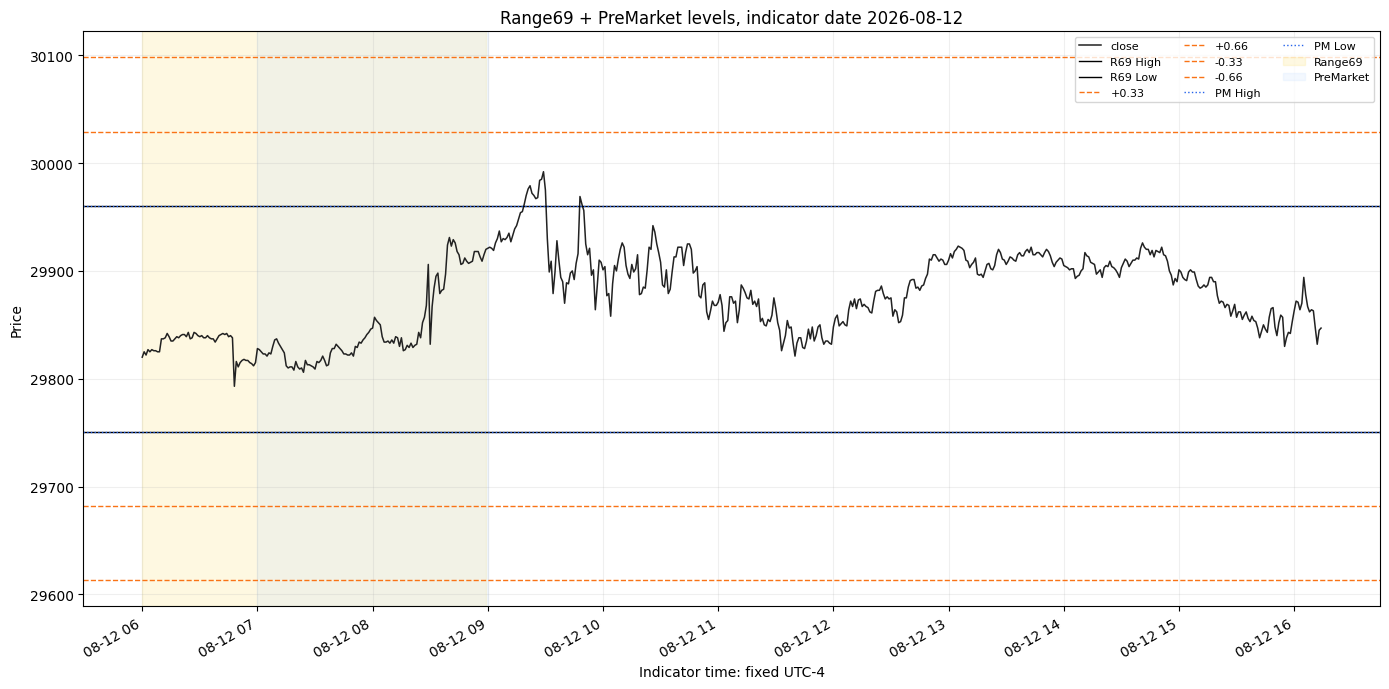

In [27]:
latest_date = stats['session_date'].iloc[-1]
day = df[(df['session_date'] == latest_date) & (df['tod_min'] >= RANGE69_START) & (df['tod_min'] <= POST_END)]
range69 = day[(day['tod_min'] >= RANGE69_START) & (day['tod_min'] <= RANGE69_END)]
premarket = day[(day['tod_min'] >= PREMARKET_START) & (day['tod_min'] <= PREMARKET_END)]

r_high = range69['high'].max()
r_low = range69['low'].min()
r_size = r_high - r_low
p_high = premarket['high'].max()
p_low = premarket['low'].min()

fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(day['dt_indicator'], day['close'], color='#222222', linewidth=1.1, label='close')

levels = [
    ('R69 High', r_high, 'black', '-'),
    ('R69 Low', r_low, 'black', '-'),
    ('+0.33', r_high + r_size * 0.33, '#f97316', '--'),
    ('+0.66', r_high + r_size * 0.66, '#f97316', '--'),
    ('-0.33', r_low - r_size * 0.33, '#f97316', '--'),
    ('-0.66', r_low - r_size * 0.66, '#f97316', '--'),
    ('PM High', p_high, '#2563eb', ':'),
    ('PM Low', p_low, '#2563eb', ':'),
]

for name, price, color, style in levels:
    ax.axhline(price, color=color, linestyle=style, linewidth=1, label=name)

ax.axvspan(range69['dt_indicator'].min(), range69['dt_indicator'].max(), color='#fde68a', alpha=0.25, label='Range69')
ax.axvspan(premarket['dt_indicator'].min(), premarket['dt_indicator'].max(), color='#bfdbfe', alpha=0.18, label='PreMarket')
ax.set_title(f'Range69 + PreMarket levels, indicator date {latest_date}')
ax.set_xlabel('Indicator time: fixed UTC-4')
ax.set_ylabel('Price')
ax.grid(True, alpha=0.2)
ax.legend(loc='best', ncol=3, fontsize=8)
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(OUT_CHART, dpi=160)
print('Saved:', OUT_CHART)
plt.show()